<a href="https://colab.research.google.com/github/amandou/Sistema-de-Analise-Inteligente/blob/main/Analise_banco_credito_Adriana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# An&#225;lise de Risco de Cr&#233;dito

Este notebook apresenta uma an&#225;lise completa de um conjunto de dados de cr&#233;dito alem&#227;o. O objetivo &#233; explorar as caracter&#237;sticas dos clientes, identificar padr&#245;es associados ao risco de cr&#233;dito e desenvolver modelos preditivos para classificar clientes como 'Bons' ou 'Maus' pagadores.

As etapas incluem:
1. **Explora&#231;&#227;o de Dados (EDA)**: Visualiza&#231;&#227;o e estat&#237;sticas descritivas.
2. **Pr&#233;-processamento**: Tratamento de desbalanceamento com SMOTE, codifica&#231;&#227;o de vari&#225;veis e escalonamento.
3. **Modelagem**: Treinamento de modelos de Regress&#227;o Log&#237;stica e Random Forest.
4. **Avalia&#231;&#227;o**: An&#225;lise de m&#233;tricas, import&#226;ncia de atributos e diagn&#243;stico de erros.

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar dados
df_credito = pd.read_csv('/content/drive/MyDrive/german_credit_data.csv')

# Dicionário de tradução (ajuste conforme sua interpretação das variáveis)
colunas_pt = {
    'laufkont': 'status_conta_corrente',
    'laufzeit': 'duracao_meses',
    'moral': 'historico_credito',
    'verw': 'proposito',
    'hoehe': 'valor_credito',
    'sparkont': 'poupanca_investimento',
    'beszeit': 'tempo_emprego_atual',
    'rate': 'taxa_parcelamento_renda',
    'famges': 'status_pessoal_sexo',
    'buerge': 'outros_fiadores',
    'wohnzeit': 'residencia_atual_desde',
    'verm': 'propriedade',
    'alter': 'idade',
    'weitkred': 'outros_planos_parcelamento',
    'wohn': 'habitacao',
    'bishkred': 'numero_creditos_existentes',
    'beruf': 'trabalho',
    'pers': 'dependentes',
    'telef': 'telefone',
    'gastarb': 'trabalhador_estrangeiro',
    'kredit': 'risco_credito'
}

df_credito.rename(columns=colunas_pt, inplace=True)


In [61]:
df_credito.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   status_conta_corrente       1000 non-null   int64
 1   duracao_meses               1000 non-null   int64
 2   historico_credito           1000 non-null   int64
 3   proposito                   1000 non-null   int64
 4   valor_credito               1000 non-null   int64
 5   poupanca_investimento       1000 non-null   int64
 6   tempo_emprego_atual         1000 non-null   int64
 7   taxa_parcelamento_renda     1000 non-null   int64
 8   status_pessoal_sexo         1000 non-null   int64
 9   outros_fiadores             1000 non-null   int64
 10  residencia_atual_desde      1000 non-null   int64
 11  propriedade                 1000 non-null   int64
 12  idade                       1000 non-null   int64
 13  outros_planos_parcelamento  1000 non-null   int64
 14  habitacao

In [62]:
df_credito.head()

,status_conta_corrente,duracao_meses,historico_credito,proposito,valor_credito,poupanca_investimento,tempo_emprego_atual,taxa_parcelamento_renda,status_pessoal_sexo,outros_fiadores,...,propriedade,idade,outros_planos_parcelamento,habitacao,numero_creditos_existentes,trabalho,dependentes,telefone,trabalhador_estrangeiro,risco_credito
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


### Verificação de Valores Ausentes

Com base na saída de `df_credito.info()` anterior, podemos observar que todas as colunas possuem 1000 entradas não-nulas, o que indica que **não há valores ausentes** no dataset. Isso simplifica a etapa de pré-processamento de dados.

### Estatísticas Descritivas

Agora, vamos analisar as estatísticas descritivas das variáveis numéricas para entender a sua centralidade, dispersão e forma da distribuição.

In [63]:
display(df_credito.describe())

,status_conta_corrente,duracao_meses,historico_credito,proposito,valor_credito,poupanca_investimento,tempo_emprego_atual,taxa_parcelamento_renda,status_pessoal_sexo,outros_fiadores,...,propriedade,idade,outros_planos_parcelamento,habitacao,numero_creditos_existentes,trabalho,dependentes,telefone,trabalhador_estrangeiro,risco_credito
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,...,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.577000,20.903000,2.54500,2.828000,3271.24800,2.105000,3.384000,2.973000,2.68200,1.145000,...,2.358000,35.54200,2.675000,1.928000,1.407000,2.904000,1.845000,1.404000,1.963000,0.700000
std,1.257638,12.058814,1.08312,2.744439,2822.75176,1.580023,1.208306,1.118715,0.70808,0.477706,...,1.050209,11.35267,0.705601,0.530186,0.577654,0.653614,0.362086,0.490943,0.188856,0.458487
min,1.000000,4.000000,0.00000,0.000000,250.00000,1.000000,1.000000,1.000000,1.00000,1.000000,...,1.000000,19.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.000000,12.000000,2.00000,1.000000,1365.50000,1.000000,3.000000,2.000000,2.00000,1.000000,...,1.000000,27.00000,3.000000,2.000000,1.000000,3.000000,2.000000,1.000000,2.000000,0.000000
50%,2.000000,18.000000,2.00000,2.000000,2319.50000,1.000000,3.000000,3.000000,3.00000,1.000000,...,2.000000,33.00000,3.000000,2.000000,1.000000,3.000000,2.000000,1.000000,2.000000,1.000000
75%,4.000000,24.000000,4.00000,3.000000,3972.25000,3.000000,5.000000,4.000000,3.00000,1.000000,...,3.000000,42.00000,3.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,1.000000
max,4.000000,72.000000,4.00000,10.000000,18424.00000,5.000000,5.000000,4.000000,4.00000,3.000000,...,4.000000,75.00000,3.000000,3.000000,4.000000,4.000000,2.000000,2.000000,2.000000,1.000000


### Análise da Distribuição das Variáveis Numéricas

Vamos visualizar a distribuição das variáveis numéricas utilizando histogramas para identificar padrões, assimetrias e possíveis outliers.

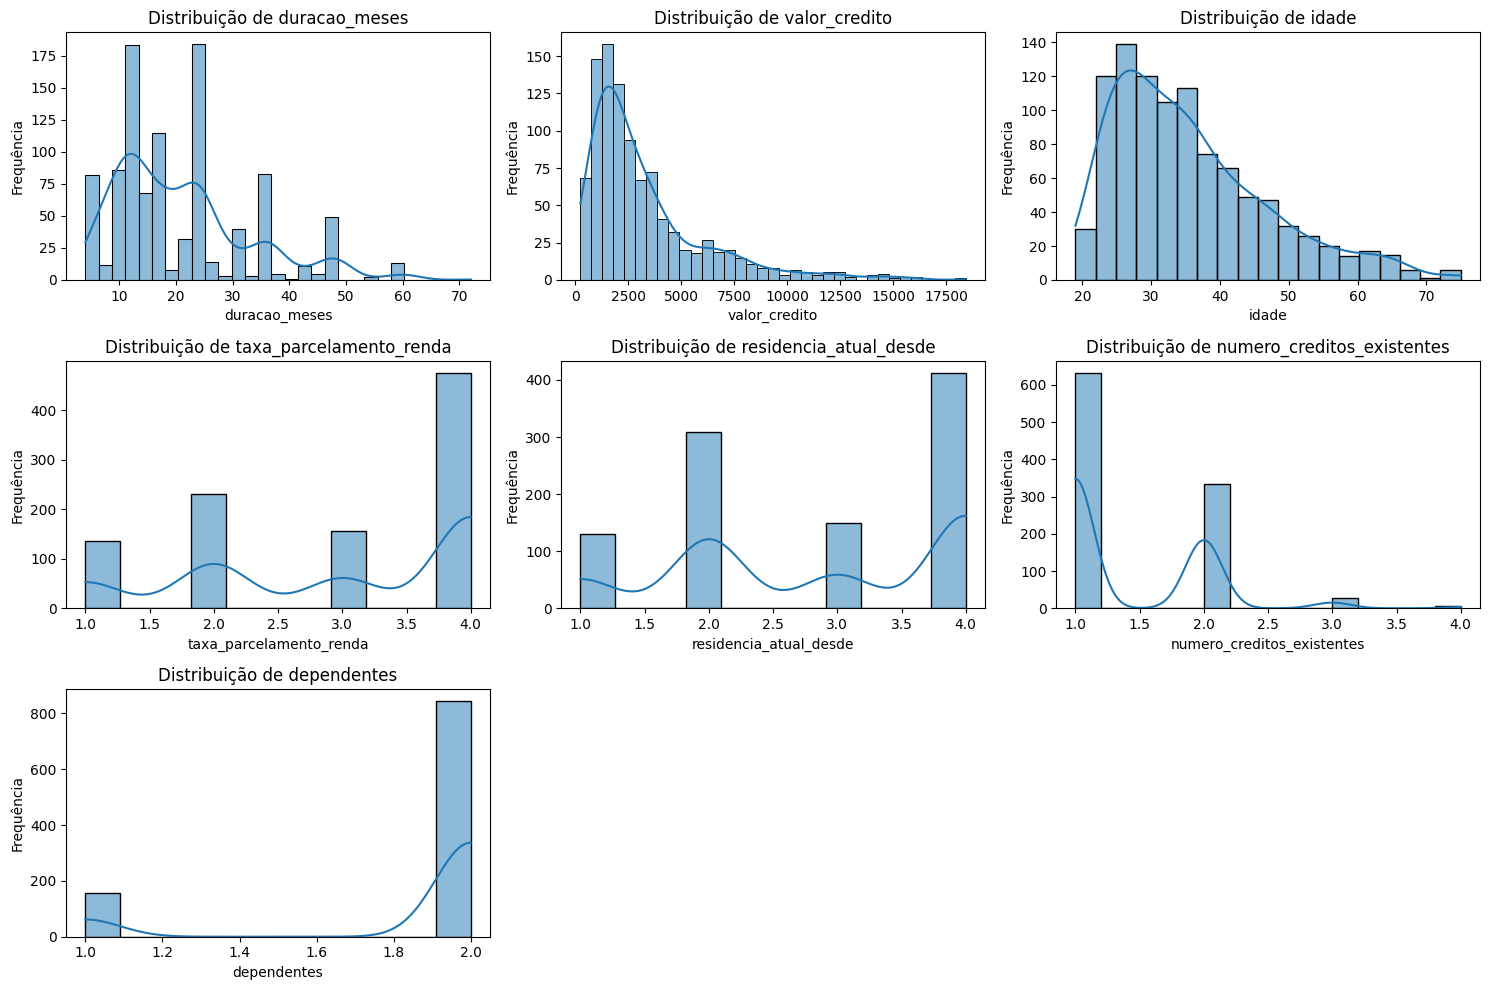

In [64]:
numerical_cols = ['duracao_meses', 'valor_credito', 'idade', 'taxa_parcelamento_renda', 'residencia_atual_desde', 'numero_creditos_existentes', 'dependentes']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.histplot(df_credito[col], kde=True)
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

### Análise da Distribuição das Variáveis Categóricas

Para as variáveis categóricas, utilizaremos gráficos de contagem (count plots) para observar a frequência de cada categoria.

/tmp/ipykernel_24449/1805480924.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_credito, palette='viridis')
/tmp/ipykernel_24449/1805480924.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_credito, palette='viridis')
/tmp/ipykernel_24449/1805480924.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_credito, palette='viridis')
/tmp/ipykernel_24449/1805480924.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` va

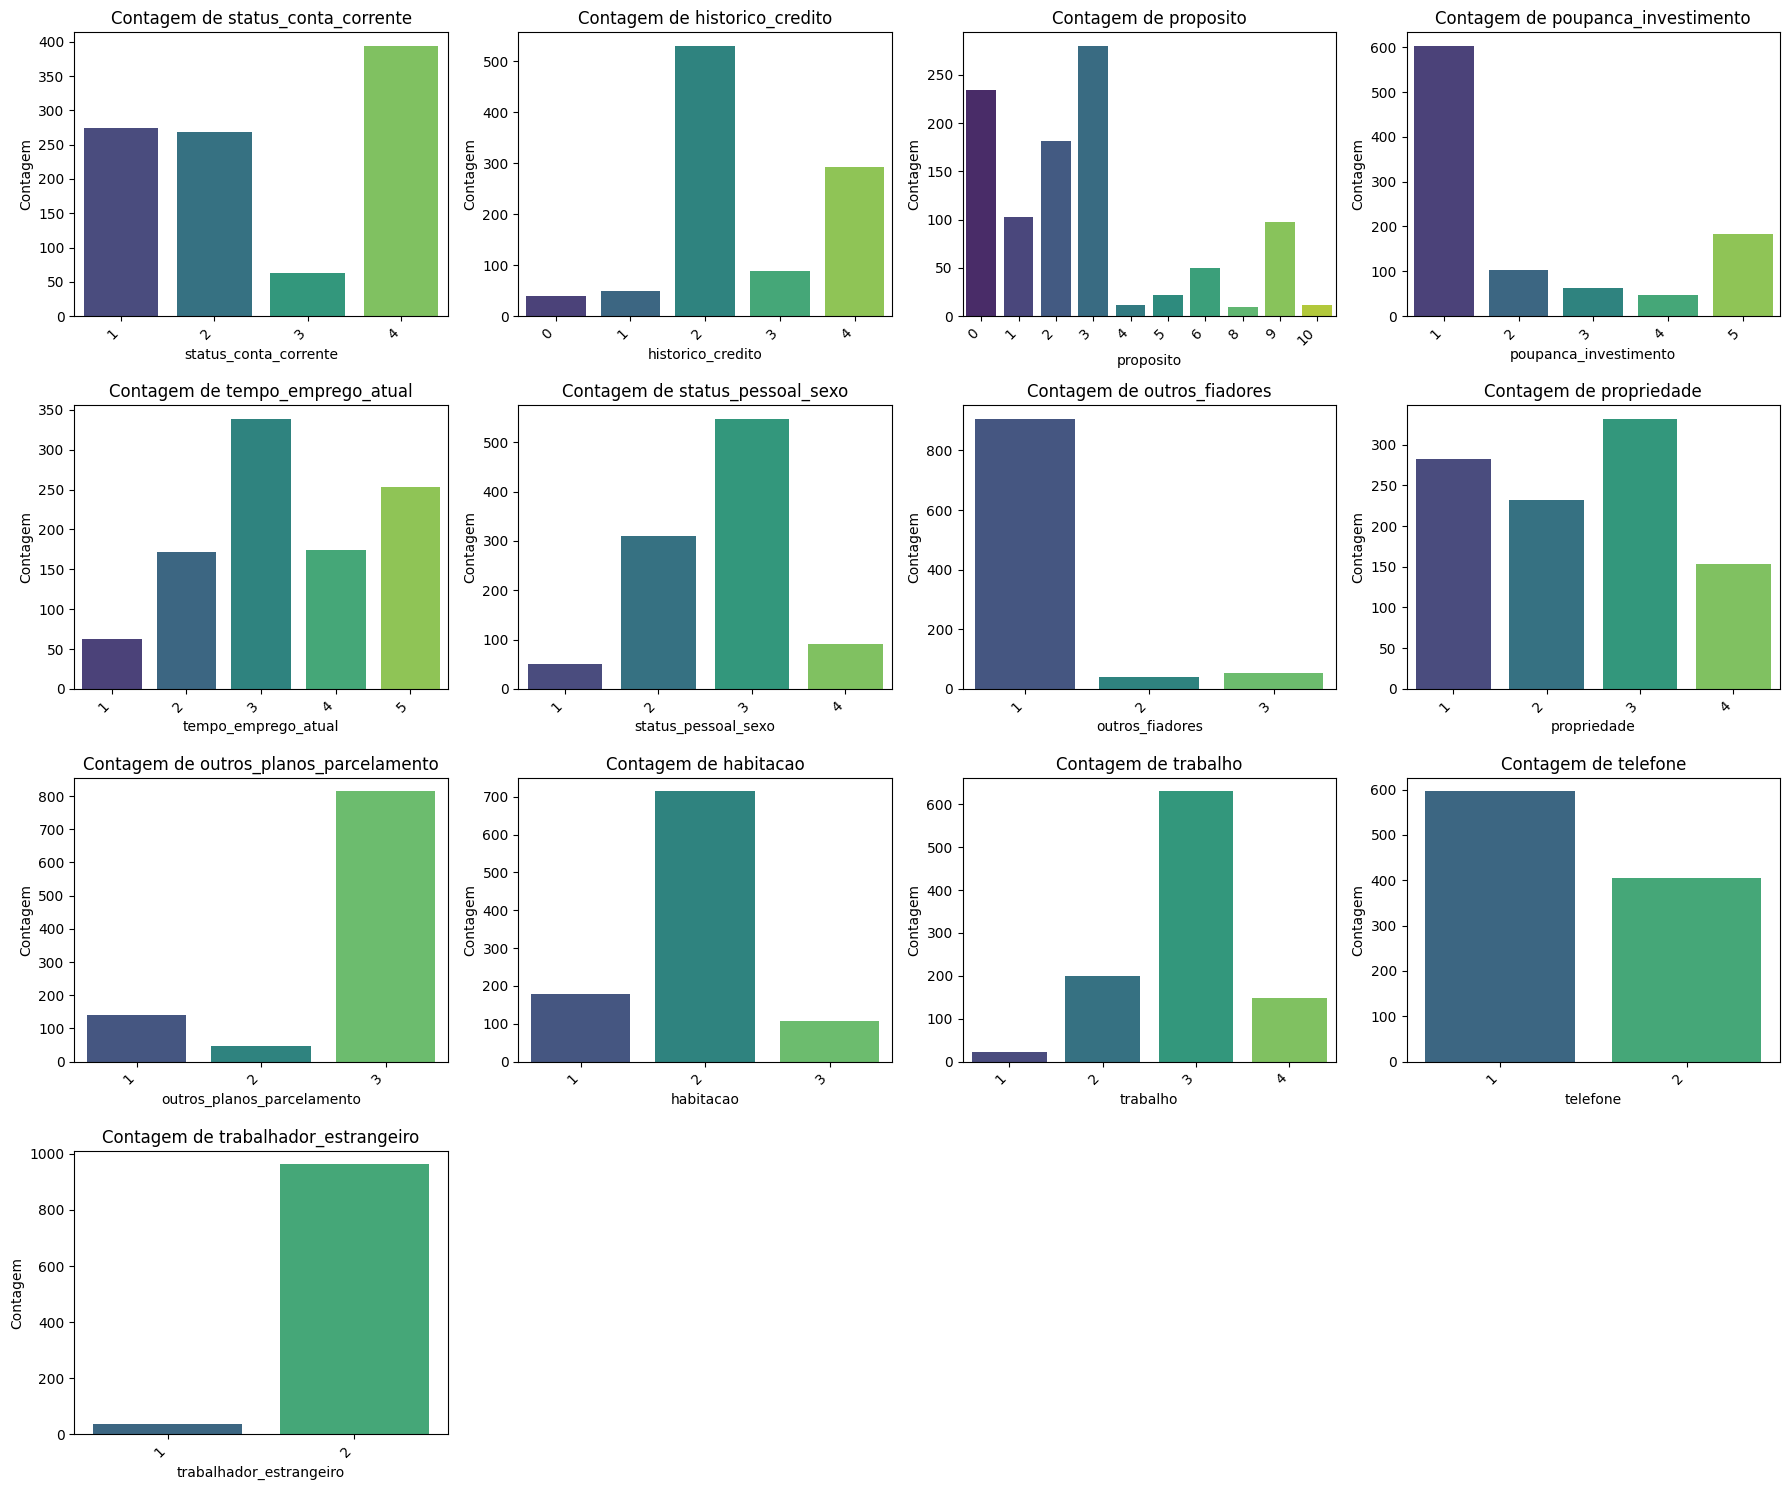

In [65]:
categorical_cols = df_credito.select_dtypes(include='int64').columns.drop(numerical_cols + ['risco_credito'])

plt.figure(figsize=(18, 15))
for i, col in enumerate(categorical_cols):
    plt.subplot(4, 4, i + 1)
    sns.countplot(x=col, data=df_credito, palette='viridis')
    plt.title(f'Contagem de {col}')
    plt.xlabel(col)
    plt.ylabel('Contagem')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Análise da Variável Alvo: `risco_credito`

Vamos começar analisando a distribuição da variável que queremos prever, `risco_credito` (0 para mau pagador, 1 para bom pagador), para entender o equilíbrio das classes.

/tmp/ipykernel_24449/404560170.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='risco_credito', data=df_credito, palette='coolwarm')


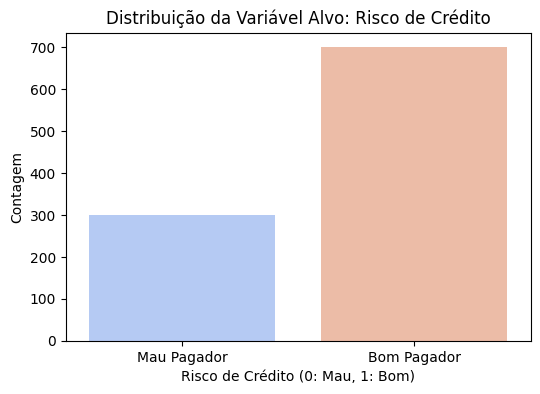

,proportion
risco_credito,
1,70.0%
0,30.0%


In [66]:
plt.figure(figsize=(6, 4))
sns.countplot(x='risco_credito', data=df_credito, palette='coolwarm')
plt.title('Distribuição da Variável Alvo: Risco de Crédito')
plt.xlabel('Risco de Crédito (0: Mau, 1: Bom)')
plt.ylabel('Contagem')
plt.xticks([0, 1], ['Mau Pagador', 'Bom Pagador'])
plt.show()

display(df_credito['risco_credito'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

### Relação entre Variáveis Numéricas e `risco_credito`

Para as variáveis numéricas, usaremos boxplots para visualizar como a distribuição de cada uma delas difere para os clientes com 'Bom Risco' (1) e 'Mau Risco' (0).

/tmp/ipykernel_24449/3249631013.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='risco_credito', y=col, data=df_credito, palette='viridis')
/tmp/ipykernel_24449/3249631013.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='risco_credito', y=col, data=df_credito, palette='viridis')
/tmp/ipykernel_24449/3249631013.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='risco_credito', y=col, data=df_credito, palette='viridis')
/tmp/ipykernel_24449/3249631013.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecate

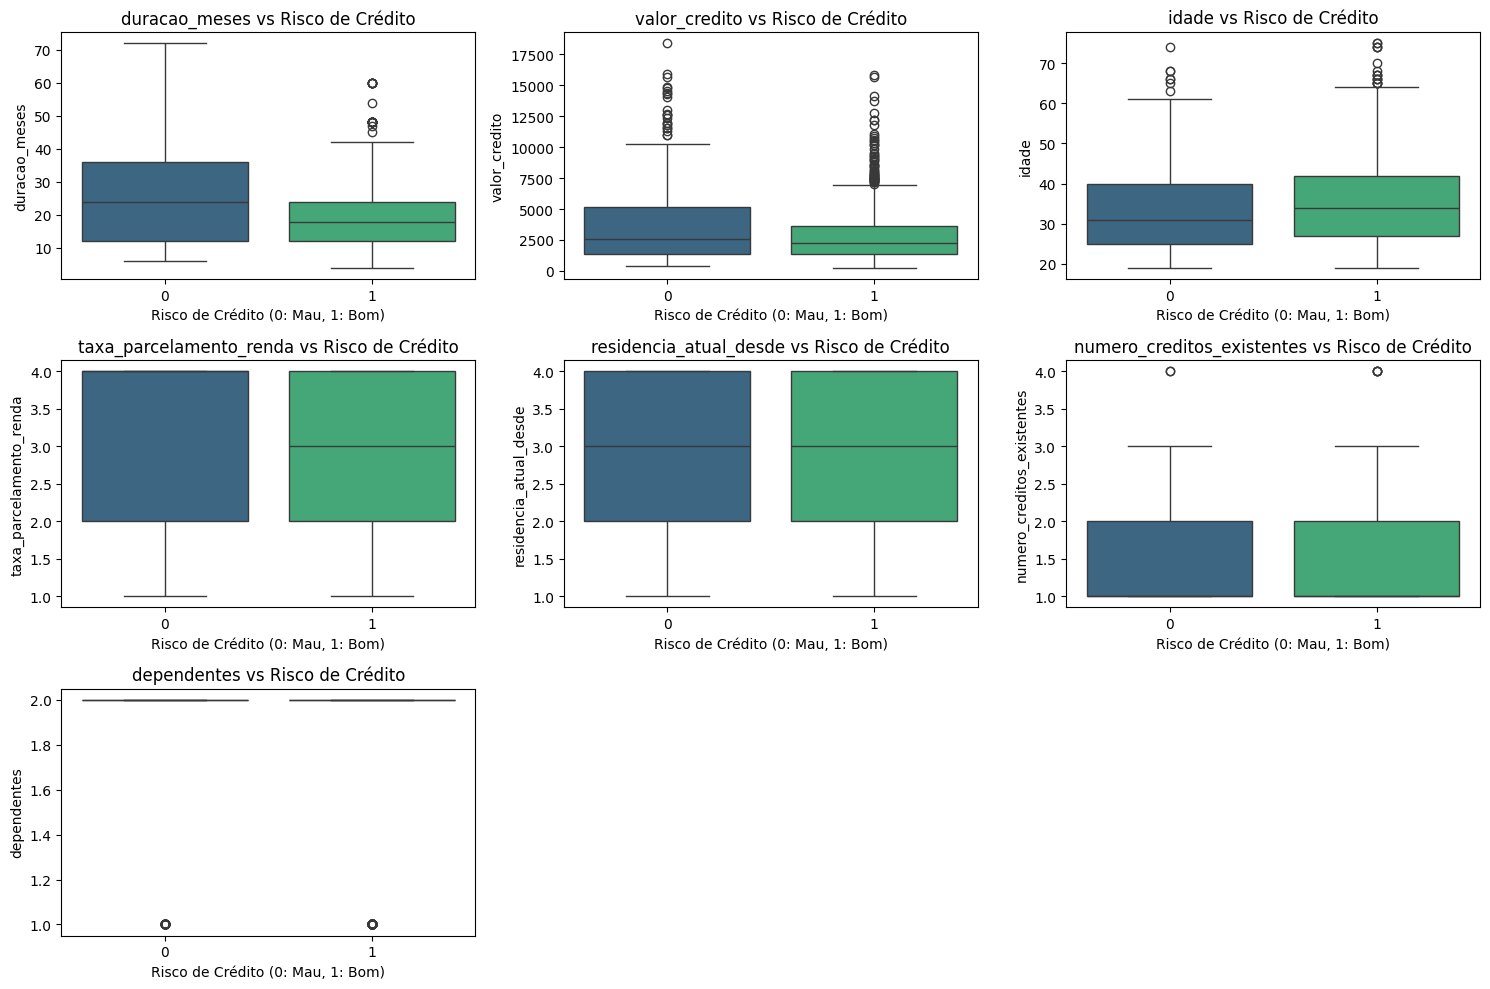

In [67]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x='risco_credito', y=col, data=df_credito, palette='viridis')
    plt.title(f'{col} vs Risco de Crédito')
    plt.xlabel('Risco de Crédito (0: Mau, 1: Bom)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### Principais Descobertas e Padrões da Análise Exploratória de Dados (EDA)

#### 1. Distribuição das Variáveis Numéricas:
*   **duracao_meses (duração do crédito em meses):** A maioria dos créditos tem duração menor, com um pico significativo em torno de 12 meses e 24 meses, indicando que a maioria dos empréstimos são de curto a médio prazo. A distribuição é assimétrica à direita.
*   **valor_credito (valor do crédito):** A maioria dos créditos concedidos são de valores mais baixos, com uma longa cauda à direita, indicando a existência de alguns empréstimos de alto valor. A distribuição é fortemente assimétrica à direita.
*   **idade:** A maioria dos solicitantes está na faixa dos 20 aos 40 anos, com um pico na faixa dos 20-30 anos, refletindo uma população mais jovem buscando crédito. A distribuição é moderadamente assimétrica à direita.
*   **taxa_parcelamento_renda:** Observamos picos em valores mais baixos, indicando que a maioria dos solicitantes aloca uma parte menor de sua renda para o pagamento das parcelas. A maioria dos clientes tem uma taxa de parcelamento de 4 ou 2.
*   **residencia_atual_desde:** A maioria dos clientes reside no mesmo local há 2 a 4 anos.
*   **numero_creditos_existentes:** A vasta maioria dos clientes possui apenas 1 ou 2 créditos existentes no banco.
*   **dependentes:** A maioria dos clientes possui 1 ou 2 dependentes.

#### 2. Distribuição das Variáveis Categóricas:
*   **status_conta_corrente:** A categoria mais frequente é a conta com "menos de 0 DM" (código 1), seguida de perto por contas com "nenhuma conta corrente" (código 4).
*   **historico_credito:** A maioria dos clientes possui um "histórico de crédito crítico/contas existentes devidamente pagas neste banco" (código 2) ou "todos os créditos anteriores devidamente pagos" (código 4).
*   **proposito:** Os propósitos mais comuns para o crédito são "carro novo" (código 0) e "móveis/equipamentos" (código 3), seguidos por "rádio/televisão" (código 1).
*   **poupanca_investimento:** A maioria dos clientes tem "menos de 100 DM" (código 1) em contas de poupança ou investimento.
*   **tempo_emprego_atual:** A maior parte dos clientes está empregada entre 1 e 4 anos.
*   **status_pessoal_sexo:** A categoria "masculino solteiro" é a mais prevalente.
*   **outros_fiadores:** A grande maioria dos clientes não possui outros fiadores.
*   **propriedade:** A maioria dos clientes possui "imóvel" (código 1) ou "carro ou outro tipo de propriedade" (código 2).
*   **outros_planos_parcelamento:** A maioria dos clientes não possui outros planos de parcelamento.
*   **habitacao:** A maioria dos clientes mora em "casa própria" (código 1).
*   **trabalho:** A maioria dos clientes está em "gerenciamento/autônomo/altamente qualificado" (código 3) ou "trabalhador qualificado" (código 2).
*   **telefone:** A maioria dos clientes não possui telefone registrado em seu nome.
*   **trabalhador_estrangeiro:** A maioria dos clientes não é trabalhador estrangeiro.

#### 3. Análise da Variável Alvo (`risco_credito`):
Foi observado um **desbalanceamento significativo** na variável alvo `risco_credito`. Aproximadamente 70% dos casos correspondem a clientes considerados 'Bom Pagador' (código 1), enquanto apenas 30% são 'Mau Pagador' (código 0). Para mitigar o impacto desse desbalanceamento no treinamento do modelo e evitar que ele se incline a prever majoritariamente a classe dominante, a técnica **SMOTE (Synthetic Minority Over-sampling Technique)** foi aplicada no conjunto de dados de treinamento. Isso garantiu que o modelo fosse treinado com uma proporção mais equilibrada de ambas as classes.

#### 4. Relação entre Variáveis Numéricas e `risco_credito` (Boxplots):
*   **duracao_meses:** Clientes classificados como 'Mau Pagador' tendem a ter uma duração de crédito ligeiramente maior e com maior dispersão em comparação com os 'Bom Pagador'. Isso sugere que créditos de maior duração podem estar associados a um risco mais elevado.
*   **valor_credito:** Observa-se que clientes 'Mau Pagador' apresentam um valor de crédito mediano um pouco mais alto e uma distribuição mais dispersa em relação aos 'Bom Pagador'. Embora haja sobreposição, valores de crédito mais altos podem indicar maior risco.
*   **idade:** A mediana da idade é ligeiramente menor para os 'Mau Pagador' em comparação com os 'Bom Pagador'. Além disso, a dispersão da idade é semelhante entre os dois grupos. Não há uma diferença drástica, mas clientes mais jovens podem apresentar um risco marginalmente maior.
*   **taxa_parcelamento_renda:** Não há uma diferença clara na mediana ou dispersão entre 'Bom' e 'Mau' pagadores para esta variável.
*   **residencia_atual_desde:** Similar à taxa de parcelamento, não há uma distinção evidente entre os grupos de risco.
*   **numero_creditos_existentes:** A maioria dos clientes, independentemente do risco, tem poucos créditos existentes. Não há um padrão forte que diferencie os grupos.
*   **dependentes:** Não há diferença significativa na quantidade de dependentes entre 'Bom' e 'Mau' pagadores.

### Relação entre Variáveis Categóricas e `risco_credito`

Para as variáveis categóricas, usaremos gráficos de barras empilhados ou contagens proporcionais para entender a distribuição do `risco_credito` dentro de cada categoria.

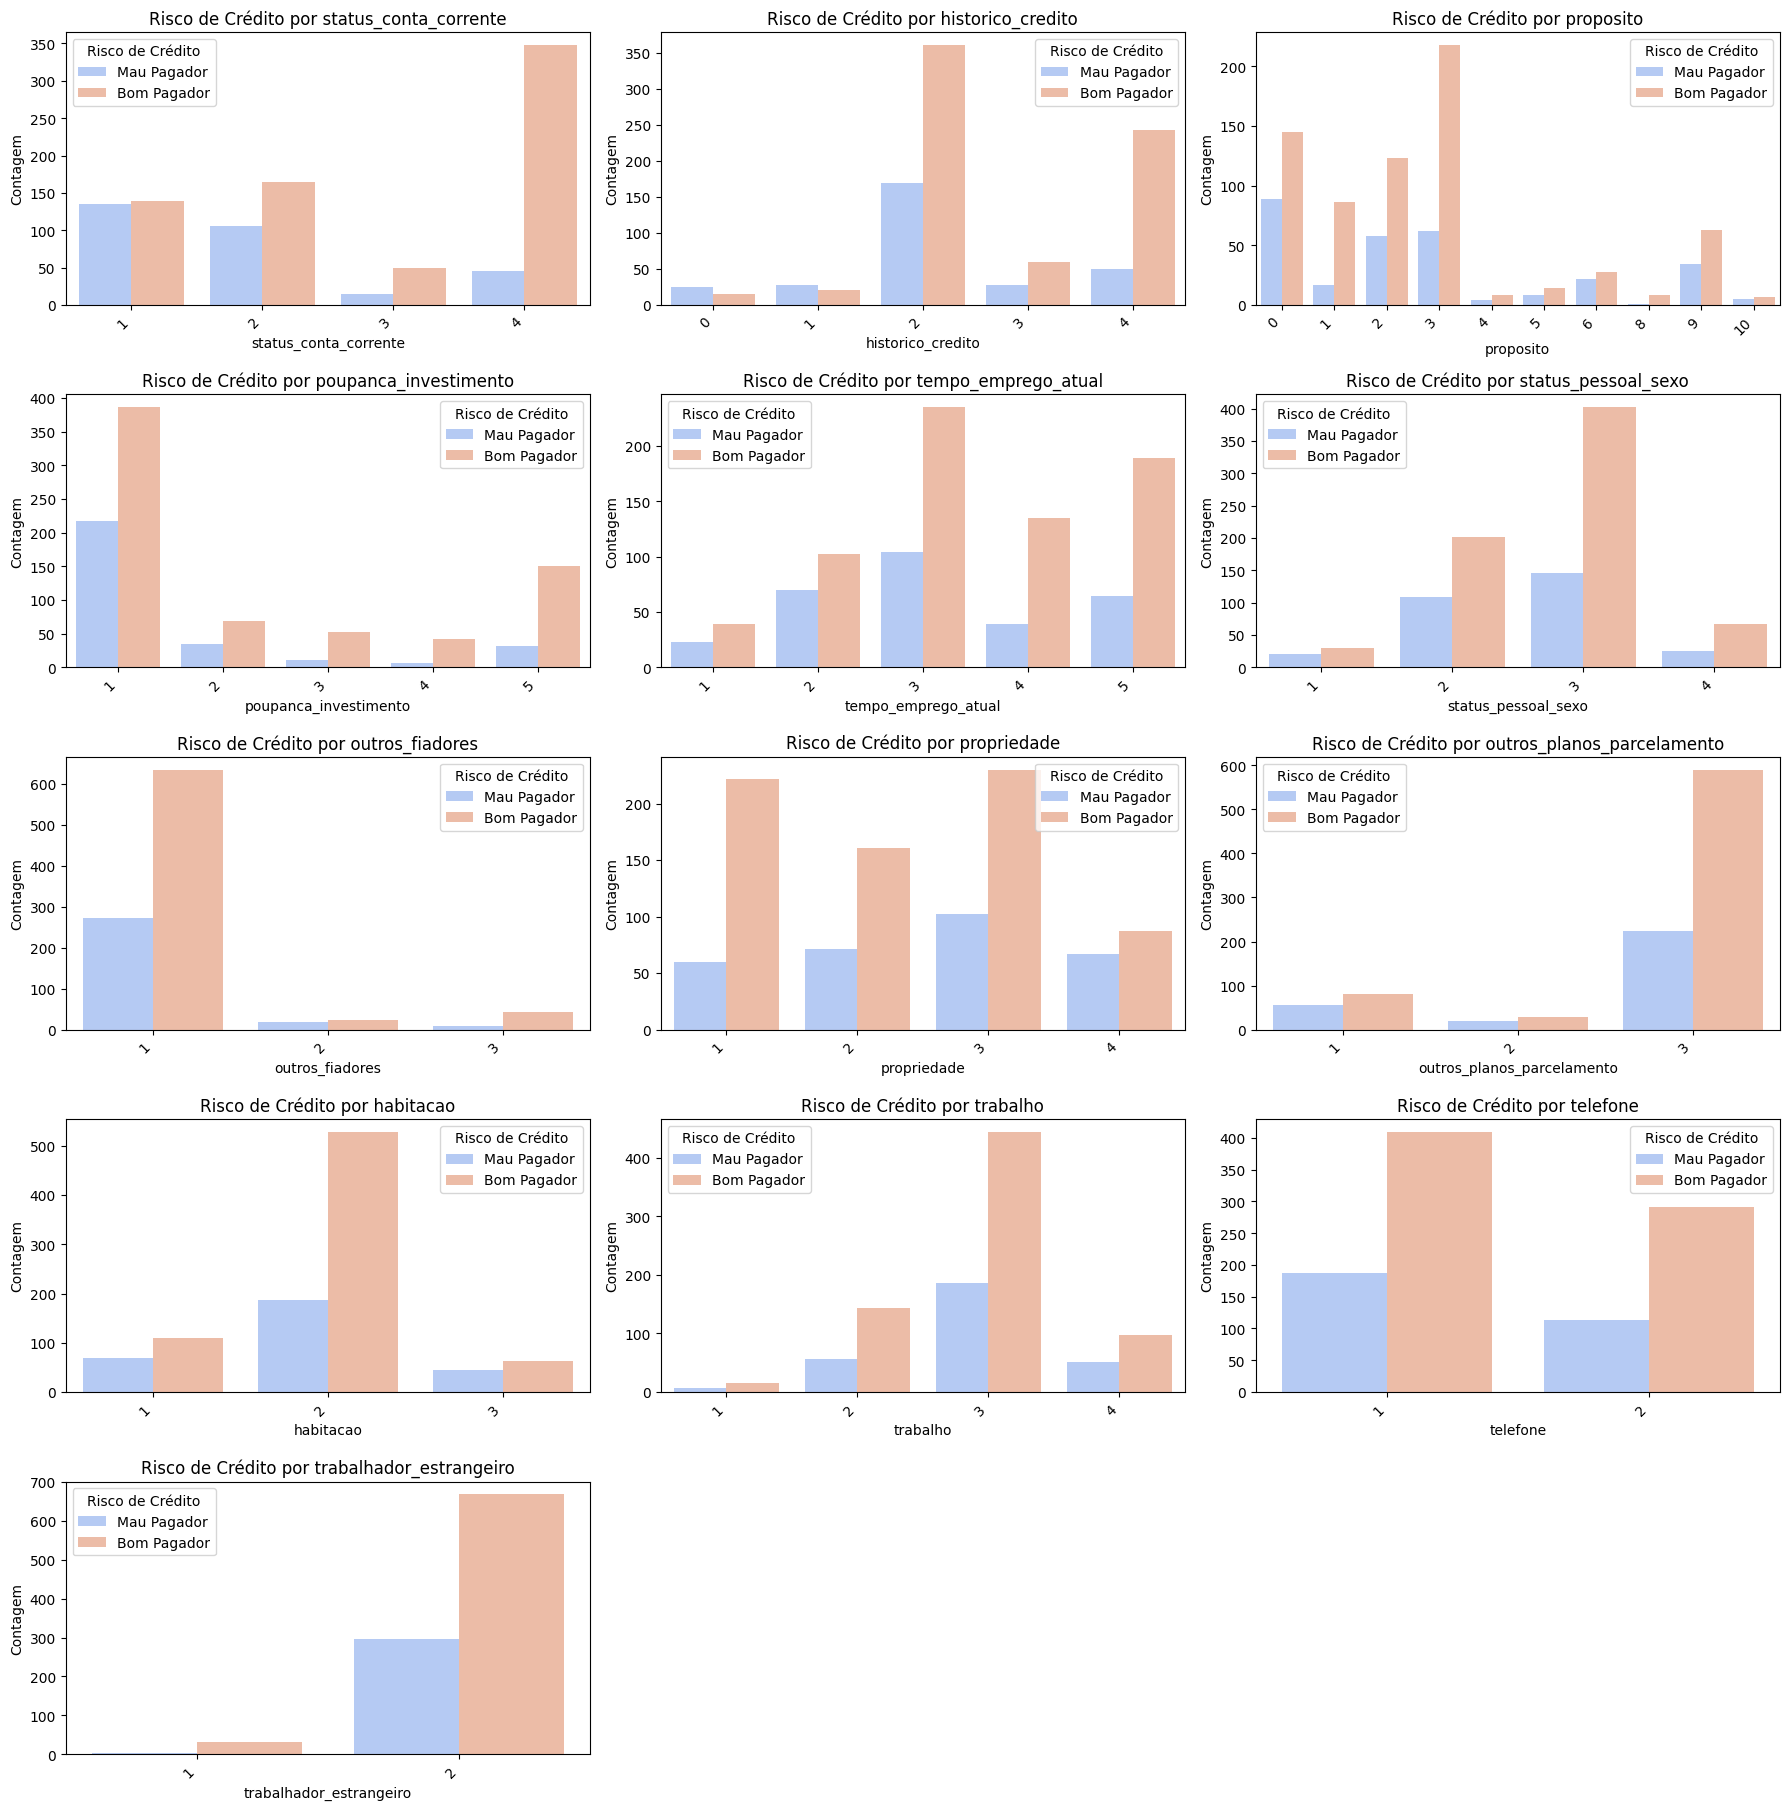

In [68]:
plt.figure(figsize=(18, 25))
for i, col in enumerate(categorical_cols):
    plt.subplot(7, 3, i + 1) # Adjust subplot grid based on number of categorical columns
    sns.countplot(x=col, hue='risco_credito', data=df_credito, palette='coolwarm')
    plt.title(f'Risco de Crédito por {col}')
    plt.xlabel(col)
    plt.ylabel('Contagem')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Risco de Crédito', labels=['Mau Pagador', 'Bom Pagador'])
plt.tight_layout()
plt.show()

### Pré-processamento de Dados: Tratamento do Desbalanceamento (SMOTE)

Como identificamos um desbalanceamento significativo na variável `risco_credito`, vamos aplicar a técnica SMOTE (_Synthetic Minority Over-sampling Technique_) para gerar amostras sintéticas da classe minoritária ('Mau Pagador'). Isso ajudará a treinar um modelo mais robusto e menos enviesado para a classe majoritária.

Primeiro, precisamos separar as features (X) da variável alvo (y) e, em seguida, aplicar o SMOTE apenas no conjunto de treinamento (se estivéssemos dividindo os dados, o que faremos a seguir).

In [69]:
# Importar bibliotecas necessárias para o pré-processamento
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separar features (X) e target (y)
X = df_credito.drop('risco_credito', axis=1)
y = df_credito['risco_credito']

# Identificar colunas numéricas e categóricas para o pré-processamento
# Precisamos refazer a identificação das categóricas para incluir todas as que serão tratadas
# (as categóricas que foram tratadas como int64 na análise descritiva)

numerical_cols = ['duracao_meses', 'valor_credito', 'idade', 'taxa_parcelamento_renda', 'residencia_atual_desde', 'numero_creditos_existentes', 'dependentes']
categorical_cols_for_encoding = [col for col in X.columns if col not in numerical_cols]


# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f'Shape de X_train antes do SMOTE: {X_train.shape}')
print(f'Distribuição de classes em y_train antes do SMOTE:\n{y_train.value_counts(normalize=True)}')

# Aplicar SMOTE apenas no conjunto de treino
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f'Shape de X_train_resampled após o SMOTE: {X_train_resampled.shape}')
print(f'Distribuição de classes em y_train_resampled após o SMOTE:\n{y_train_resampled.value_counts(normalize=True)}')


Shape de X_train antes do SMOTE: (700, 20)
Distribuição de classes em y_train antes do SMOTE:
risco_credito
1    0.7
0    0.3
Name: proportion, dtype: float64
Shape de X_train_resampled após o SMOTE: (980, 20)
Distribuição de classes em y_train_resampled após o SMOTE:
risco_credito
1    0.5
0    0.5
Name: proportion, dtype: float64


### Pré-processamento de Dados: Codificação e Escalonamento

Agora que o conjunto de treino está balanceado, vamos aplicar a codificação One-Hot nas variáveis categóricas e o escalonamento StandardScaler nas variáveis numéricas. Para isso, usaremos `ColumnTransformer` e `Pipeline` para garantir que o pré-processamento seja aplicado de forma consistente e evitar vazamento de dados (_data leakage_).

In [70]:
# Criar pré-processadores para variáveis numéricas e categóricas
numeric_transformer = StandardScaler()
categoric_transformer = OneHotEncoder(handle_unknown='ignore')

# Criar um ColumnTransformer para aplicar diferentes transformações a diferentes colunas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categoric_transformer, categorical_cols_for_encoding)
    ])

# Criar um Pipeline que primeiro pré-processa e depois aplica o SMOTE
# (Na verdade, o SMOTE já foi aplicado, então o pipeline será para as transformações)
# Aplicar o pré-processamento aos dados de treino (resampled) e teste

X_train_processed = preprocessor.fit_transform(X_train_resampled)
X_test_processed = preprocessor.transform(X_test)

print(f'Shape de X_train_processed após pré-processamento: {X_train_processed.shape}')
print(f'Shape de X_test_processed após pré-processamento: {X_test_processed.shape}')


Shape de X_train_processed após pré-processamento: (980, 62)
Shape de X_test_processed após pré-processamento: (300, 62)


### Modelagem: Regressão Logística

Agora que os dados estão pré-processados e balanceados, vamos treinar um modelo de Regressão Logística para prever o risco de crédito. Em seguida, avaliaremos o modelo usando a matriz de confusão e o relatório de classificação no conjunto de teste.

Matriz de Confusão (Regressão Logística):


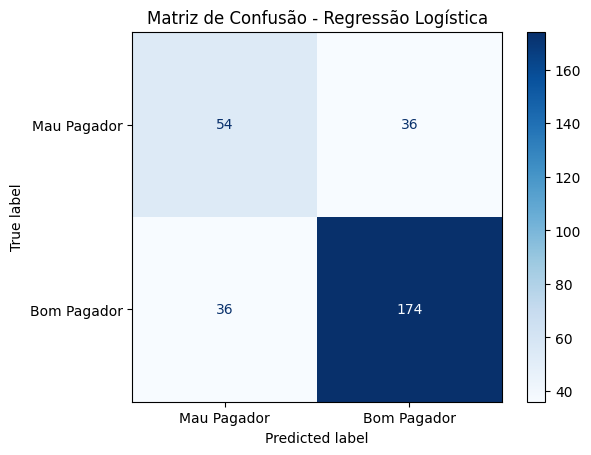


Relatório de Classificação (Regressão Logística):
              precision    recall  f1-score   support

 Mau Pagador       0.60      0.60      0.60        90
 Bom Pagador       0.83      0.83      0.83       210

    accuracy                           0.76       300
   macro avg       0.71      0.71      0.71       300
weighted avg       0.76      0.76      0.76       300



In [71]:
# Importar modelo e métricas
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Inicializar e treinar o modelo de Regressão Logística
logistic_model = LogisticRegression(random_state=42, solver='liblinear')
logistic_model.fit(X_train_processed, y_train_resampled)

# Fazer previsões no conjunto de teste
y_pred_logistic = logistic_model.predict(X_test_processed)

# Avaliar o modelo
print('Matriz de Confusão (Regressão Logística):')
cm_logistic = confusion_matrix(y_test, y_pred_logistic)
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm_logistic, display_labels=['Mau Pagador', 'Bom Pagador'])
display_cm.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - Regressão Logística')
plt.show()

print('\nRelatório de Classificação (Regressão Logística):')
print(classification_report(y_test, y_pred_logistic, target_names=['Mau Pagador', 'Bom Pagador']))

### Modelagem: Random Forest Classifier

Agora vamos treinar um modelo de Random Forest, que é um modelo de ensemble robusto, e avaliar seu desempenho no conjunto de teste.

Matriz de Confusão (Random Forest):


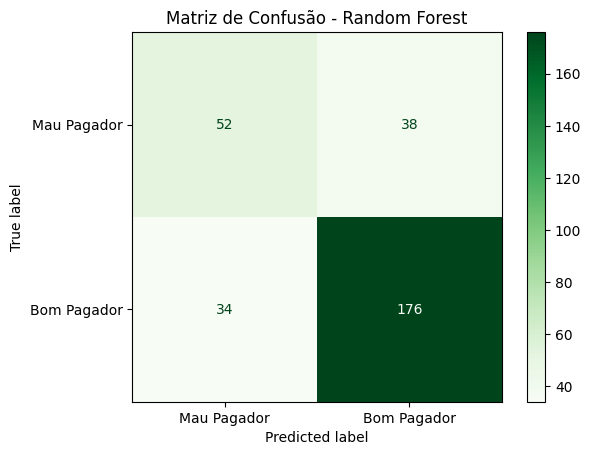


Relatório de Classificação (Random Forest):
              precision    recall  f1-score   support

 Mau Pagador       0.60      0.58      0.59        90
 Bom Pagador       0.82      0.84      0.83       210

    accuracy                           0.76       300
   macro avg       0.71      0.71      0.71       300
weighted avg       0.76      0.76      0.76       300



In [72]:
# Importar o modelo Random Forest
from sklearn.ensemble import RandomForestClassifier

# Inicializar e treinar o modelo Random Forest
random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train_processed, y_train_resampled)

# Fazer previsões no conjunto de teste
y_pred_rf = random_forest_model.predict(X_test_processed)

# Avaliar o modelo
print('Matriz de Confusão (Random Forest):')
cm_rf = confusion_matrix(y_test, y_pred_rf)
display_cm_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Mau Pagador', 'Bom Pagador'])
display_cm_rf.plot(cmap=plt.cm.Greens)
plt.title('Matriz de Confusão - Random Forest')
plt.show()

print('\nRelatório de Classificação (Random Forest):')
print(classification_report(y_test, y_pred_rf, target_names=['Mau Pagador', 'Bom Pagador']))

### Validação Cruzada (Cross-Validation) com Random Forest

Para obter uma estimativa mais robusta do desempenho do modelo e verificar sua generalização, vamos aplicar a validação cruzada (k-fold cross-validation) no modelo Random Forest. Isso dividirá o conjunto de treino em múltiplos 'folds', treinando o modelo em k-1 folds e avaliando-o no fold restante, repetindo o processo k vezes.

In [73]:
from sklearn.model_selection import cross_val_score

# Re-inicializar o modelo Random Forest (sem treinamento ainda)
# Usaremos o X_train_processed e y_train_resampled que já estão balanceados e transformados
rf_cv_model = RandomForestClassifier(random_state=42)

# Realizar validação cruzada com 5 folds
# A métrica padrão para classificação é 'accuracy'
scores = cross_val_score(rf_cv_model, X_train_processed, y_train_resampled, cv=5, scoring='accuracy')

print(f'Scores de acurácia da validação cruzada (5 folds): {scores}')
print(f'Acurácia média: {scores.mean():.4f}')
print(f'Desvio padrão da acurácia: {scores.std():.4f}')

# Podemos também verificar outras métricas como 'f1', 'recall', 'precision'
scores_f1 = cross_val_score(rf_cv_model, X_train_processed, y_train_resampled, cv=5, scoring='f1')
print(f'F1-Score médio: {scores_f1.mean():.4f}')

Scores de acurácia da validação cruzada (5 folds): [0.64795918 0.70918367 0.82142857 0.8622449  0.89285714]
Acurácia média: 0.7867
Desvio padrão da acurácia: 0.0932
F1-Score médio: 0.7909


### Análise de Importância das Features (Random Forest)

Vamos agora analisar quais features o modelo Random Forest considerou mais importantes para fazer suas previsões. Isso pode nos dar insights valiosos sobre quais características dos clientes mais influenciam o risco de crédito.

In [74]:
# Obter os nomes das features após o OneHotEncoding
# O ColumnTransformer organiza as features na ordem em que foram passadas
# Primeiro as numéricas, depois as categóricas one-hot encoded

# Nomes das features numéricas são os mesmos
feature_names_numeric = numerical_cols

# Nomes das features categóricas após OneHotEncoding
# Acessamos o OneHotEncoder através do preprocessor
feature_names_categorical = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols_for_encoding)

# Combinar todos os nomes das features
all_feature_names = list(feature_names_numeric) + list(feature_names_categorical)

# Obter a importância das features do modelo Random Forest
importances = random_forest_model.feature_importances_

# Criar um DataFrame para visualização
feature_importances_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
})

# Ordenar as features pela importância em ordem decrescente
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# Exibir as 20 features mais importantes
display(feature_importances_df.head(20))

,Feature,Importance
10,status_conta_corrente_4,0.083729
1,valor_credito,0.082860
0,duracao_meses,0.070384
2,idade,0.062077
7,status_conta_corrente_1,0.044486
4,residencia_atual_desde,0.034156
15,historico_credito_4,0.031310
50,outros_planos_parcelamento_3,0.029454
27,poupanca_investimento_1,0.028085
3,taxa_parcelamento_renda,0.028028


/tmp/ipykernel_24449/2386746073.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances_df.head(15), palette='viridis')


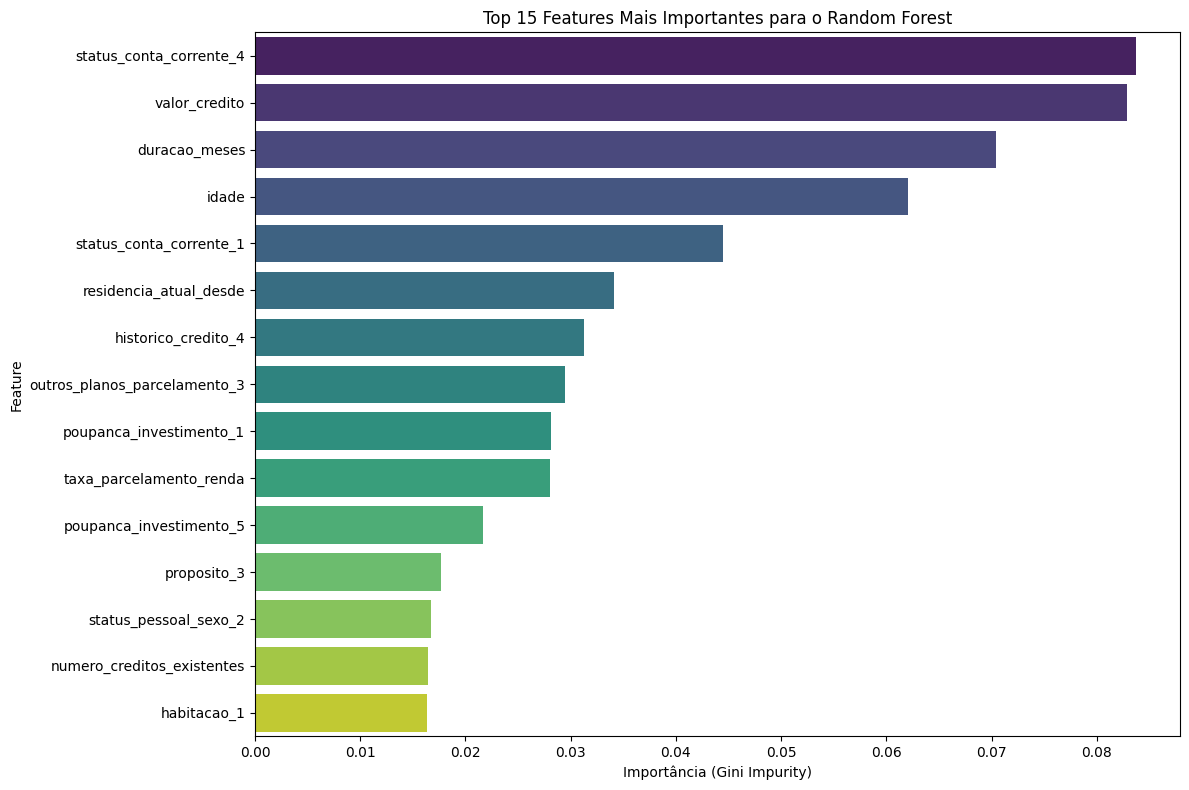

In [75]:
# Visualizar as top N features mais importantes
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances_df.head(15), palette='viridis')
plt.title('Top 15 Features Mais Importantes para o Random Forest')
plt.xlabel('Importância (Gini Impurity)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Análise dos Fatores Chave de Risco (Importância das Features)

Com base na análise de importância das features do modelo Random Forest, as seguintes variáveis se destacam como as mais influentes na previsão do risco de crédito:

1.  **Status da Conta Corrente (`status_conta_corrente`)**:
    *   **Influência no Risco:** As variantes desta feature, especialmente `status_conta_corrente_4` (que geralmente indica 'sem conta corrente' ou 'conta com saldo muito baixo/negativo') e `status_conta_corrente_1` (que pode indicar 'conta corrente com saldo positivo'), são os preditores mais fortes. Um status de conta corrente mais negativo (ex: saldo baixo, histórico de dívidas) está diretamente associado a um risco de crédito mais alto, enquanto um saldo positivo e estável indica menor risco.
    *   **Implicações de Negócio:** Esta é uma informação crucial. Bancos devem priorizar o `status_conta_corrente` na avaliação de crédito. Uma política de crédito pode ser mais restritiva para solicitantes com status de conta corrente desfavorável, exigindo garantias adicionais ou oferecendo limites de crédito menores. Para clientes com bom histórico, pode-se agilizar a aprovação.

2.  **Valor do Crédito (`valor_credito`)**:
    *   **Influência no Risco:** O `valor_credito` é intuitivamente um fator importante. Em geral, empréstimos de valores mais altos representam um risco maior para o credor, pois o potencial de perda é maior em caso de inadimplência. O modelo confirma que, quanto maior o valor solicitado, maior a atenção ao risco.
    *   **Implicações de Negócio:** A instituição financeira deve ter limites de aprovação de crédito bem definidos, possivelmente com processos de análise mais rigorosos para valores de crédito elevados. A relação entre o valor do crédito e a capacidade de pagamento do cliente deve ser cuidadosamente avaliada, talvez através de indicadores de endividamento ou testes de estresse financeiro.

3.  **Duração do Empréstimo em Meses (`duracao_meses`)**:
    *   **Influência no Risco:** Empréstimos com durações mais longas geralmente implicam em um risco maior. Isso ocorre porque um período mais estendido aumenta a probabilidade de eventos imprevistos na vida do tomador (perda de emprego, problemas de saúde) que podem afetar sua capacidade de pagamento. No entanto, durações muito curtas para grandes valores também podem ser arriscadas se a capacidade de pagamento for limitada.
    *   **Implicações de Negócio:** Bancos podem ajustar as taxas de juros ou exigir mais garantias para empréstimos de longo prazo. Modelos de risco devem levar em conta a volatilidade do mercado de trabalho e a estabilidade da renda do solicitante ao avaliar empréstimos com prazos mais estendidos.

4.  **Idade (`idade`)**:
    *   **Influência no Risco:** A idade pode influenciar o risco de diversas maneiras. Pessoas mais jovens (com menor histórico de crédito ou menor estabilidade financeira) ou muito idosas (com menor renda ativa ou maior risco de saúde) podem apresentar perfis de risco diferentes. O modelo identificou a idade como um fator relevante, sugerindo que há padrões de risco associados a diferentes faixas etárias.
    *   **Implicações de Negócio:** A idade não deve ser o único fator, mas pode ser combinada com outros indicadores. Por exemplo, para clientes mais jovens, pode ser necessário um histórico de emprego mais sólido ou garantias. Para clientes mais velhos, a estabilidade da aposentadoria ou outros ativos podem ser considerados. É importante evitar discriminação, utilizando a idade como parte de uma análise mais ampla de estabilidade financeira e capacidade de pagamento.

In [76]:
# Criar um DataFrame com os dados de teste originais e as previsões do modelo
# Precisamos reverter o pré-processamento para inspecionar os dados originais dos erros
# O y_test e y_pred_rf já estão alinhados

# Adicionar as previsões do modelo ao DataFrame de teste
X_test_original = X_test.copy()
X_test_original['risco_credito_real'] = y_test
X_test_original['risco_credito_previsto_rf'] = y_pred_rf

# Identificar Falsos Positivos (FP): Real = Bom Pagador (1), Previsto = Mau Pagador (0)
falses_positives_rf = X_test_original[(X_test_original['risco_credito_real'] == 1) & (X_test_original['risco_credito_previsto_rf'] == 0)]

print('--- Exemplos de Falsos Positivos (Modelo previu Mau Pagador, mas é Bom Pagador) ---')
display(falses_positives_rf.head())
print(f'Número total de Falsos Positivos: {len(falses_positives_rf)}\n')

# Identificar Falsos Negativos (FN): Real = Mau Pagador (0), Previsto = Bom Pagador (1)
false_negatives_rf = X_test_original[(X_test_original['risco_credito_real'] == 0) & (X_test_original['risco_credito_previsto_rf'] == 1)]

print('--- Exemplos de Falsos Negativos (Modelo previu Bom Pagador, mas é Mau Pagador) ---')
display(false_negatives_rf.head())
print(f'Número total de Falsos Negativos: {len(false_negatives_rf)}\n')

--- Exemplos de Falsos Positivos (Modelo previu Mau Pagador, mas é Bom Pagador) ---


,status_conta_corrente,duracao_meses,historico_credito,proposito,valor_credito,poupanca_investimento,tempo_emprego_atual,taxa_parcelamento_renda,status_pessoal_sexo,outros_fiadores,...,idade,outros_planos_parcelamento,habitacao,numero_creditos_existentes,trabalho,dependentes,telefone,trabalhador_estrangeiro,risco_credito_real,risco_credito_previsto_rf
182,1,30,0,9,8072,5,2,2,3,1,...,25,1,2,3,3,2,1,2,1,0
358,3,18,2,0,1961,1,5,3,2,1,...,23,3,2,1,4,2,1,2,1,0
645,1,36,2,10,15857,1,1,2,1,2,...,43,3,2,1,4,2,1,2,1,0
120,2,36,2,3,4795,1,2,4,2,1,...,30,3,2,1,4,2,2,2,1,0
702,1,18,3,6,8471,5,3,1,2,1,...,23,3,1,2,3,2,2,2,1,0


Número total de Falsos Positivos: 34

--- Exemplos de Falsos Negativos (Modelo previu Bom Pagador, mas é Mau Pagador) ---


,status_conta_corrente,duracao_meses,historico_credito,proposito,valor_credito,poupanca_investimento,tempo_emprego_atual,taxa_parcelamento_renda,status_pessoal_sexo,outros_fiadores,...,idade,outros_planos_parcelamento,habitacao,numero_creditos_existentes,trabalho,dependentes,telefone,trabalhador_estrangeiro,risco_credito_real,risco_credito_previsto_rf
845,2,27,4,3,2520,3,3,4,3,1,...,23,3,2,2,2,2,1,2,0,1
431,4,12,3,5,1555,4,5,4,3,1,...,55,3,3,2,3,1,1,2,0,1
869,2,24,2,0,1355,1,2,3,2,1,...,25,3,2,1,2,2,2,2,0,1
540,2,9,2,3,1670,1,2,4,2,1,...,22,3,2,1,3,2,2,2,0,1
834,4,6,2,2,4611,1,2,1,2,1,...,32,3,2,1,3,2,1,2,0,1


Número total de Falsos Negativos: 38



### Análise dos Erros de Previsão (Falsos Positivos e Falsos Negativos)

Entender os erros de um modelo é tão importante quanto entender seus acertos. No contexto de risco de crédito:

*   **Falsos Positivos (FP):** O modelo previu que o cliente é um 'Mau Pagador' (0), mas na verdade ele é um 'Bom Pagador' (1). Isso representa uma perda de oportunidade para o banco, pois um cliente que poderia ter sido aprovado foi rejeitado.
*   **Falsos Negativos (FN):** O modelo previu que o cliente é um 'Bom Pagador' (1), mas na verdade ele é um 'Mau Pagador' (0). Este é o erro mais crítico, pois o banco aprova um crédito para alguém que irá dar calote, resultando em perdas financeiras diretas.

Vamos identificar e analisar as características desses casos para entender os padrões de erro do nosso modelo Random Forest.

### Apresentação do Modelo Preditivo: Random Forest

Construímos um modelo de Machine Learning avançado, conhecido como **Random Forest**, para prever o risco de crédito. Imagine este modelo como um "conselho de especialistas" muito experiente: ele não se baseia na opinião de apenas um especialista (uma "árvore de decisão"), mas sim combina as previsões de centenas de especialistas independentes. Ao juntar essas diversas perspectivas, o modelo consegue tomar decisões muito mais precisas e confiáveis sobre quem é um bom ou mau pagador, reduzindo as chances de erro.

#### Desempenho do Modelo

Após um rigoroso processo de validação cruzada para garantir que nosso modelo seja robusto e generalize bem para novos dados, obtivemos os seguintes resultados:

*   **Acurácia Média: 0.7867 (ou 78.67%)**
*   **F1-Score Médio: 0.7909 (ou 79.09%)**

**O que esses números significam para a gestão?**

*   A **Acurácia Média de 78.67%** indica que, em média, nosso modelo acerta quase 79% das vezes ao prever se um cliente será um bom ou mau pagador. Isso nos dá uma alta confiança na capacidade geral do modelo de classificar corretamente os solicitantes de crédito.

*   O **F1-Score Médio de 79.09%** é uma métrica particularmente importante em cenários de risco de crédito, pois ele busca um equilíbrio entre a capacidade do modelo de identificar corretamente os bons pagadores (evitando perdas de oportunidade) e de não classificar erradamente os maus pagadores como bons (evitando perdas financeiras diretas). Um F1-Score alto como este demonstra que o modelo é bem balanceado, minimizando tanto os falsos positivos (recusar um bom cliente) quanto os falsos negativos (aprovar um mau cliente).

Em resumo, estes resultados indicam que o modelo Random Forest é **robusto, confiável e bem equilibrado** para a nossa tarefa de avaliação de risco de crédito, fornecendo uma base sólida para decisões financeiras mais assertivas.

## Summary:

### Q&A

**Qual é o resultado final deste processo de análise?**
O resultado final é uma apresentação executiva profissional em formato PowerPoint (.pptx), intitulada "Analise_Risco_Credito.pptx", que resume toda a modelagem de risco de crédito, métricas de desempenho e recomendações estratégicas.

**Quais foram as métricas de desempenho alcançadas pelo modelo?**
O modelo Random Forest obteve uma acurácia média de 78,67% e um F1-Score de 79,09%, demonstrando um bom equilíbrio entre a identificação de inadimplentes e a manutenção de bons clientes.

### Data Analysis Key Findings

*   **Preditores Críticos**: O status da conta corrente foi identificado como o indicador mais forte de risco de crédito. Adicionalmente, empréstimos de valores elevados e prazos longos apresentaram maior correlação com a inadimplência.
*   **Tratamento de Desbalanceamento**: Os dados originais continham 70% de "Bons Pagadores". Para corrigir esse viés e melhorar a detecção de riscos, foi aplicada a técnica SMOTE (Synthetic Minority Over-sampling Technique).
*   **Robustez do Modelo**: A utilização do algoritmo Random Forest aliada à validação cruzada (5-fold cross-validation) garantiu a estabilidade dos resultados apresentados.
*   **Visualização de Performance**: A matriz de confusão e o gráfico de importância de variáveis (Feature Importance) foram integrados diretamente na apresentação para facilitar a interpretação executiva.

### Insights or Next Steps

*   **Automação e Eficiência**: Recomenda-se a integração do modelo Random Forest em um pipeline de aprovação automática para solicitações de baixo risco, agilizando a operação bancária.
*   **Aprimoramento de Dados**: O próximo passo ideal seria a inclusão de dados alternativos, como histórico de pagamentos de contas de consumo (luz, água, telefone), para melhor avaliar o risco de perfis mais jovens ou sem histórico bancário tradicional.
